# Bibliotekos

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn import svm
from sklearn.ensemble import AdaBoostClassifier as AdaBoost
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import SGDClassifier

# Duomenų paruošimas

In [2]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [3]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.6, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 5746


# Normavimas

In [4]:
def min_max_normalization(x):
    return (x - x.min()) / (x.max() - x.min())

def denormalize(df_norm, orig_min, orig_max):
    return df_norm * (orig_max - orig_min) + orig_min

numeric_cols = sampled_data.select_dtypes(include=[np.number])

orig_min = numeric_cols.min()
orig_max = numeric_cols.max()

min_max_data = numeric_cols.apply(min_max_normalization)

min_max_data  = min_max_data.drop(['int.rate', 'installment', 'log.annual.inc'], axis=1)

categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

min_max_data.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
0,0.088433,0.404762,0.252568,0.001987,0.901408,0.000000,0.0,0.0,0.015852
1,0.034633,0.285714,0.199361,0.002988,0.413146,0.129032,0.0,0.0,0.050594
2,0.504371,0.214286,0.000000,0.000000,0.448826,0.032258,0.0,0.0,0.001032
3,0.336247,0.333333,0.218260,0.000000,0.203756,0.129032,0.0,0.0,0.087396
4,0.187962,0.547619,0.408971,0.003766,0.646948,0.193548,0.0,0.0,0.050684


In [5]:
debt_data = full_min_max_data[full_min_max_data['purpose'] == 'debt_consolidation']
credit_data = full_min_max_data[full_min_max_data['purpose'] == 'credit_card']

In [6]:
X_train_debt, X_test_debt, y_train_debt, y_test_debt = train_test_split(debt_data.iloc[:, :-3], debt_data['credit.policy'], test_size=0.2, random_state=123)

X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(credit_data.iloc[:, :-3], credit_data['credit.policy'], test_size=0.2, random_state=123)

In [7]:
X_debt, y_debt = debt_data.iloc[:, :-3], debt_data['credit.policy']

X_credit, y_credit = credit_data.iloc[:, :-3], credit_data['credit.policy']

# Algoritmai su numatytais parametrais

## SVC

### Konsolidavimo grupė

In [8]:
X_debt.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
2156,0.887693,0.380952,0.209670,0.004251,0.388732,0.064516,0.000000,0.0,0.021151
2157,0.437794,0.333333,0.111737,0.007828,0.312676,0.129032,0.000000,0.0,0.017471
2158,0.656355,0.261905,0.249184,0.006993,0.311737,0.129032,0.076923,0.0,0.017716
2159,0.544385,0.261905,0.353991,0.004550,0.781221,0.129032,0.000000,0.0,0.029003
2160,0.891728,0.238095,0.142833,0.017642,0.615023,0.129032,0.000000,0.0,0.026156


In [9]:
print(y_debt.value_counts())
y_debt.head()

credit.policy
1    1934
0     440
Name: count, dtype: int64


2156    0
2157    0
2158    0
2159    0
2160    0
Name: credit.policy, dtype: category
Categories (2, int64): [0, 1]

In [10]:
SVC = svm.SVC()
cv_strategy = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

scores_svc_debt = cross_val_score(SVC, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_svc_debt

array([0.89915966, 0.94117647, 0.92436975, 0.90756303, 0.93277311,
       0.91596639, 0.91596639, 0.95798319, 0.8907563 , 0.8907563 ,
       0.92436975, 0.88235294, 0.94117647, 0.94117647, 0.91525424,
       0.87288136, 0.88983051, 0.89830508, 0.90677966, 0.91525424])

### Kredito grupė

In [11]:
scores_svc_credit = cross_val_score(SVC, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_svc_credit

array([0.84210526, 0.81578947, 0.89473684, 0.81578947, 0.81578947,
       0.84210526, 0.86842105, 0.84210526, 0.89473684, 0.94736842,
       0.92105263, 0.92105263, 0.86842105, 0.86842105, 0.94736842,
       0.89473684, 0.84210526, 0.83783784, 0.91891892, 0.83783784])

## AdaBoost

### Konsolidavimo grupė

In [12]:
scores_AdaBoost_debt = cross_val_score(AdaBoost(), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_AdaBoost_debt

array([0.95798319, 0.96638655, 0.97478992, 0.98319328, 1.        ,
       1.        , 0.99159664, 0.98319328, 0.98319328, 0.96638655,
       0.94957983, 0.94957983, 0.94117647, 1.        , 0.96610169,
       0.91525424, 0.96610169, 0.95762712, 0.96610169, 0.96610169])

### Kredito grupė

In [13]:
scores_AdaBoost_credit = cross_val_score(AdaBoost(), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_AdaBoost_credit

array([0.97368421, 0.92105263, 0.92105263, 0.86842105, 0.92105263,
       0.89473684, 0.92105263, 0.94736842, 0.94736842, 1.        ,
       0.94736842, 0.94736842, 0.97368421, 0.89473684, 0.94736842,
       0.94736842, 0.97368421, 0.97297297, 1.        , 0.97297297])

## Bernoulli naive bayes

### Konsolidavimo grupė

In [14]:
scores_BernoulliNB_debt = cross_val_score(BernoulliNB(), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_BernoulliNB_debt

array([0.81512605, 0.81512605, 0.81512605, 0.81512605, 0.82352941,
       0.81512605, 0.81512605, 0.81512605, 0.81512605, 0.81512605,
       0.81512605, 0.81512605, 0.81512605, 0.81512605, 0.81355932,
       0.81355932, 0.81355932, 0.80508475, 0.81355932, 0.81355932])

### Kredito grupė

In [15]:
scores_BernoulliNB_credit = cross_val_score(BernoulliNB(), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_BernoulliNB_credit

array([0.78947368, 0.76315789, 0.78947368, 0.78947368, 0.81578947,
       0.81578947, 0.81578947, 0.78947368, 0.78947368, 0.81578947,
       0.78947368, 0.84210526, 0.81578947, 0.81578947, 0.81578947,
       0.78947368, 0.84210526, 0.81081081, 0.81081081, 0.81081081])

---

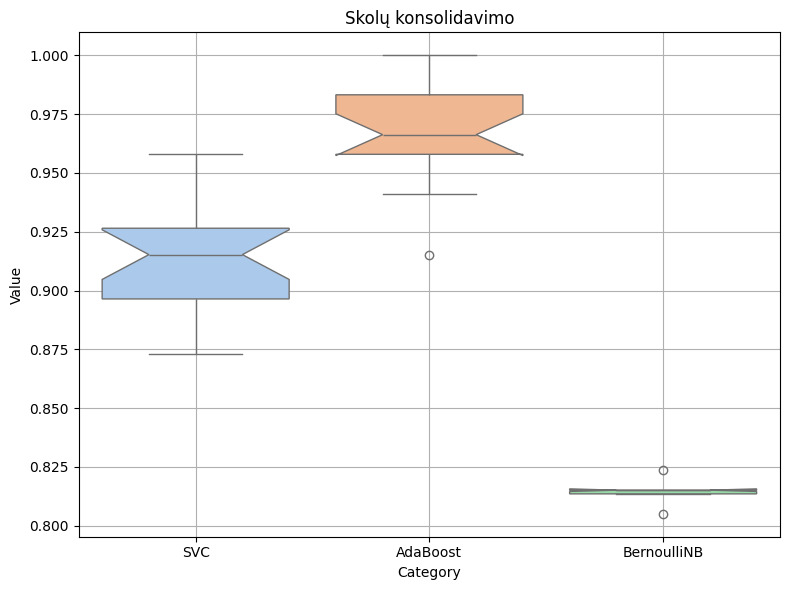

In [16]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20,
    'Value': np.concatenate([scores_svc_debt, scores_AdaBoost_debt, scores_BernoulliNB_debt])
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.grid()
plt.tight_layout()

plt.show()

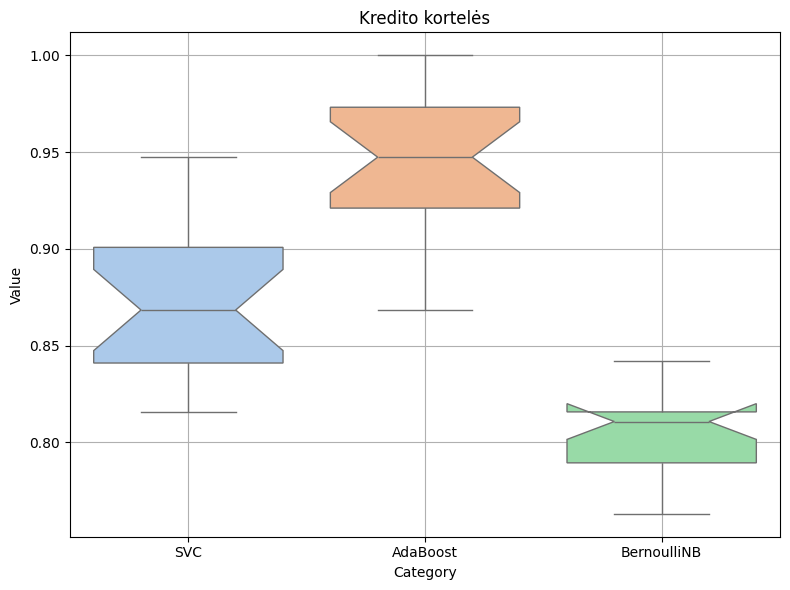

In [17]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20,
    'Value': np.concatenate([scores_svc_credit, scores_AdaBoost_credit, scores_BernoulliNB_credit])
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.grid()
plt.tight_layout()

plt.show()

## Logistic Regression

### Konsolidavimo grupė

In [18]:
scores_lr_debt = cross_val_score(LogisticRegression(), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_lr_debt

array([0.8487395 , 0.8907563 , 0.86554622, 0.87394958, 0.89915966,
       0.88235294, 0.90756303, 0.89915966, 0.87394958, 0.88235294,
       0.91596639, 0.85714286, 0.91596639, 0.91596639, 0.92372881,
       0.8559322 , 0.86440678, 0.8559322 , 0.88135593, 0.87288136])

### Kredito grupė

In [19]:
scores_lr_credit = cross_val_score(LogisticRegression(), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_lr_credit

array([0.78947368, 0.84210526, 0.81578947, 0.81578947, 0.78947368,
       0.81578947, 0.81578947, 0.84210526, 0.84210526, 0.84210526,
       0.86842105, 0.86842105, 0.81578947, 0.81578947, 0.89473684,
       0.84210526, 0.84210526, 0.81081081, 0.89189189, 0.83783784])

## Gradient Boosting

### Konsolidavimo grupė

In [20]:
scores_gb_debt = cross_val_score(GradientBoostingClassifier(), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_gb_debt

array([1.        , 0.99159664, 1.        , 1.        , 1.        ,
       1.        , 0.99159664, 0.98319328, 1.        , 0.98319328,
       0.98319328, 0.98319328, 0.99159664, 1.        , 0.99152542,
       0.97457627, 0.99152542, 0.99152542, 0.99152542, 0.99152542])

### Kredito grupė

In [21]:
scores_gb_credit = cross_val_score(GradientBoostingClassifier(), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_gb_credit

array([1.        , 1.        , 1.        , 0.97368421, 0.94736842,
       0.92105263, 1.        , 1.        , 0.97368421, 1.        ,
       1.        , 0.97368421, 1.        , 0.94736842, 0.94736842,
       0.92105263, 0.97368421, 1.        , 0.97297297, 1.        ])

## Gaussian Naive Bayes

### Konsolidavimo grupė

In [22]:
scores_gnb_debt = cross_val_score(GaussianNB(), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_gnb_debt

array([0.87394958, 0.85714286, 0.90756303, 0.88235294, 0.8487395 ,
       0.89915966, 0.88235294, 0.8907563 , 0.85714286, 0.88235294,
       0.81512605, 0.89915966, 0.86554622, 0.89915966, 0.88135593,
       0.87288136, 0.86440678, 0.88983051, 0.8559322 , 0.87288136])

### Kredito grupė

In [23]:
scores_gnb_credit = cross_val_score(GaussianNB(), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_gnb_credit

array([0.78947368, 0.86842105, 0.92105263, 0.76315789, 0.63157895,
       0.84210526, 0.94736842, 0.81578947, 0.84210526, 0.92105263,
       0.84210526, 0.78947368, 0.81578947, 0.81578947, 0.86842105,
       0.73684211, 0.76315789, 0.78378378, 0.91891892, 0.75675676])

----

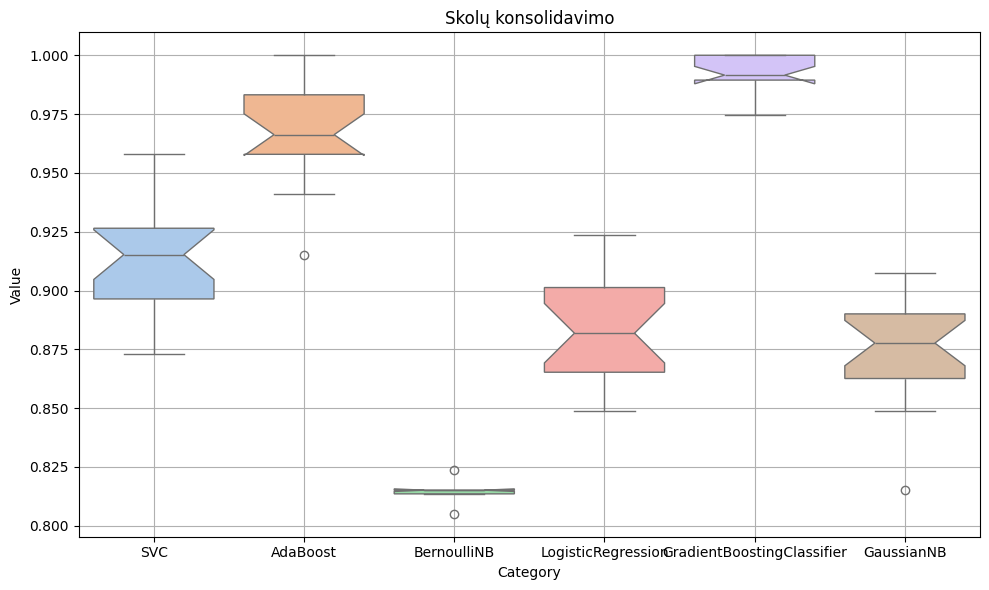

In [24]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20,
    'Value': np.concatenate([scores_svc_debt, scores_AdaBoost_debt, scores_BernoulliNB_debt, scores_lr_debt, scores_gb_debt, scores_gnb_debt])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.grid()
plt.tight_layout()

plt.show()

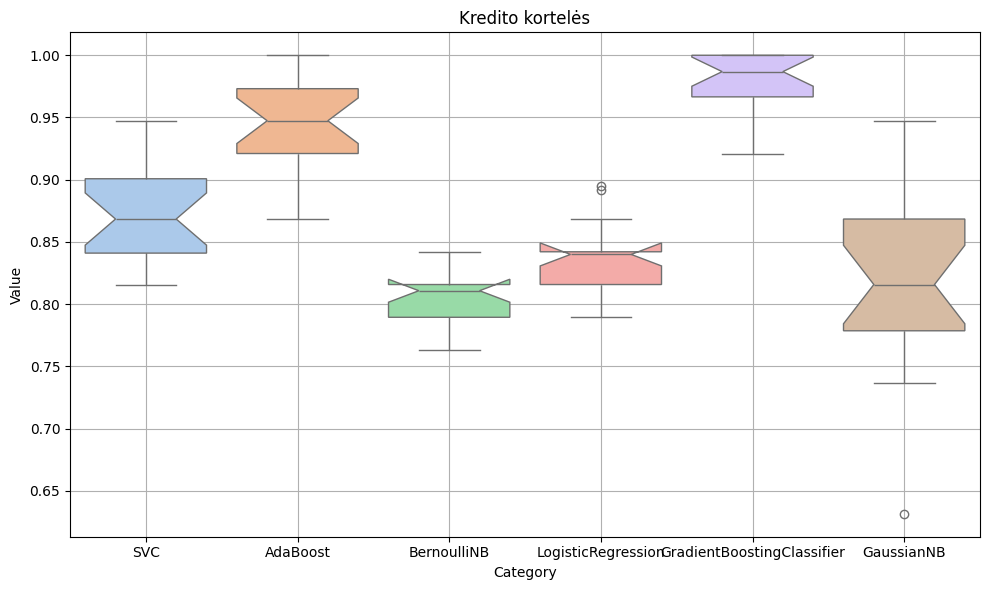

In [25]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20,
    'Value': np.concatenate([scores_svc_credit, scores_AdaBoost_credit, scores_BernoulliNB_credit, scores_lr_credit, scores_gb_credit, scores_gnb_credit])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.grid()
plt.tight_layout()

plt.show()

## Random Forest

### Konsolidavimo grupė

In [26]:
scores_rf_debt = cross_val_score(RandomForestClassifier(), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_rf_debt

array([1.        , 0.98319328, 0.99159664, 1.        , 1.        ,
       1.        , 0.99159664, 0.99159664, 0.99159664, 0.97478992,
       0.99159664, 0.98319328, 0.97478992, 1.        , 0.97457627,
       0.95762712, 1.        , 0.99152542, 0.98305085, 0.99152542])

### Kredito grupė

In [27]:
scores_rf_credit = cross_val_score(RandomForestClassifier(), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_rf_credit

array([1.        , 0.97368421, 1.        , 0.97368421, 0.94736842,
       0.92105263, 0.97368421, 1.        , 0.97368421, 1.        ,
       1.        , 1.        , 0.94736842, 0.94736842, 0.94736842,
       0.97368421, 0.97368421, 0.97297297, 1.        , 1.        ])

## K-Nearest Neighbors

### Konsolidavimo grupė

In [28]:
scores_knn_debt = cross_val_score(KNeighborsClassifier(), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_knn_debt

array([0.88235294, 0.8907563 , 0.8907563 , 0.8907563 , 0.8907563 ,
       0.8907563 , 0.92436975, 0.92436975, 0.86554622, 0.90756303,
       0.8907563 , 0.8487395 , 0.87394958, 0.89915966, 0.89830508,
       0.83898305, 0.88983051, 0.86440678, 0.88135593, 0.88983051])

### Kredito grupė

In [29]:
scores_knn_credit = cross_val_score(KNeighborsClassifier(), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_knn_credit

array([0.81578947, 0.81578947, 0.84210526, 0.84210526, 0.84210526,
       0.81578947, 0.84210526, 0.81578947, 0.86842105, 0.97368421,
       0.94736842, 0.86842105, 0.84210526, 0.89473684, 0.89473684,
       0.86842105, 0.81578947, 0.89189189, 0.89189189, 0.83783784])

## Passive Aggressive

### Konsolidavimo grupė

In [30]:
scores_pa_debt = cross_val_score(PassiveAggressiveClassifier(), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_pa_debt

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

array([0.86554622, 0.72268908, 0.91596639, 0.90756303, 0.90756303,
       0.90756303, 0.91596639, 0.88235294, 0.94117647, 0.60504202,
       0.87394958, 0.86554622, 0.88235294, 0.93277311, 0.92372881,
       0.8559322 , 0.89830508, 0.88983051, 0.86440678, 0.88135593])

### Kredito grupė

In [31]:
scores_pa_credit = cross_val_score(PassiveAggressiveClassifier(), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_pa_credit

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

array([0.84210526, 0.86842105, 0.84210526, 0.81578947, 0.81578947,
       0.84210526, 0.89473684, 0.89473684, 0.86842105, 1.        ,
       0.86842105, 0.86842105, 0.86842105, 0.86842105, 0.92105263,
       0.84210526, 0.84210526, 0.89189189, 0.86486486, 0.86486486])

## Passive Aggressive --> SGD

### Konsolidavimo grupė

In [32]:
scores_sgd_debt = cross_val_score(SGDClassifier(loss="hinge", penalty=None, learning_rate="pa1", eta0=1.0), X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
scores_sgd_debt

array([0.90756303, 0.94117647, 0.92436975, 0.91596639, 0.93277311,
       0.92436975, 0.90756303, 0.92436975, 0.90756303, 0.89915966,
       0.89915966, 0.89915966, 0.89915966, 0.92436975, 0.88983051,
       0.89830508, 0.74576271, 0.88983051, 0.88983051, 0.91525424])

### Kredito grupė

In [33]:
scores_sgd_credit = cross_val_score(SGDClassifier(loss="hinge", penalty=None, learning_rate="pa1", eta0=1.0), X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
scores_sgd_credit

array([0.71052632, 0.89473684, 0.86842105, 0.84210526, 0.68421053,
       0.84210526, 0.89473684, 0.84210526, 0.84210526, 0.97368421,
       0.76315789, 0.97368421, 0.89473684, 0.86842105, 0.89473684,
       0.84210526, 0.86842105, 0.86486486, 0.89189189, 0.83783784])

-----

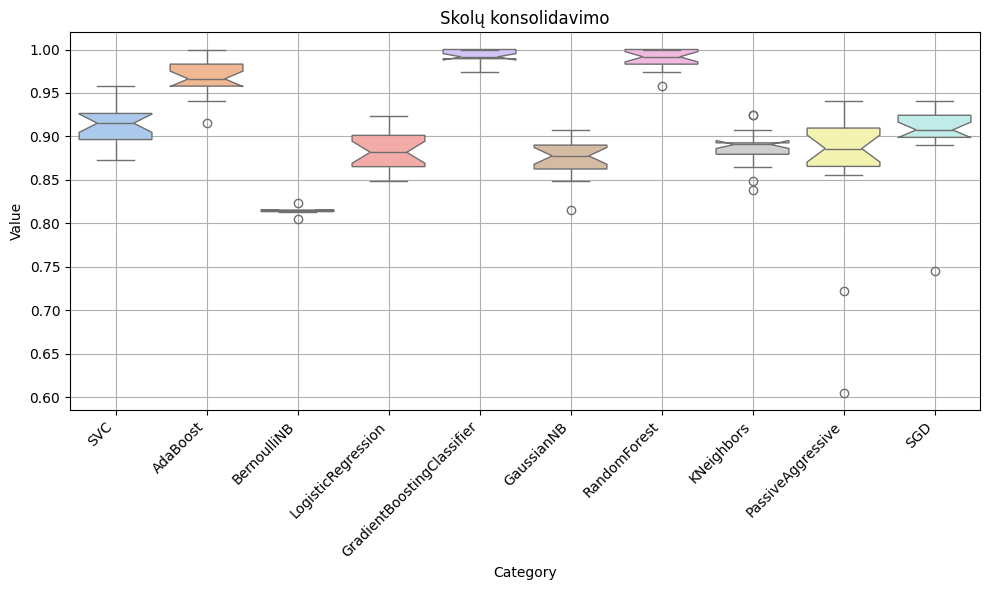

In [34]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20 + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20 + ['SGD']*20,
    'Value': np.concatenate([scores_svc_debt, scores_AdaBoost_debt, scores_BernoulliNB_debt, scores_lr_debt, scores_gb_debt, scores_gnb_debt, scores_rf_debt, scores_knn_debt, scores_pa_debt, scores_sgd_debt])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

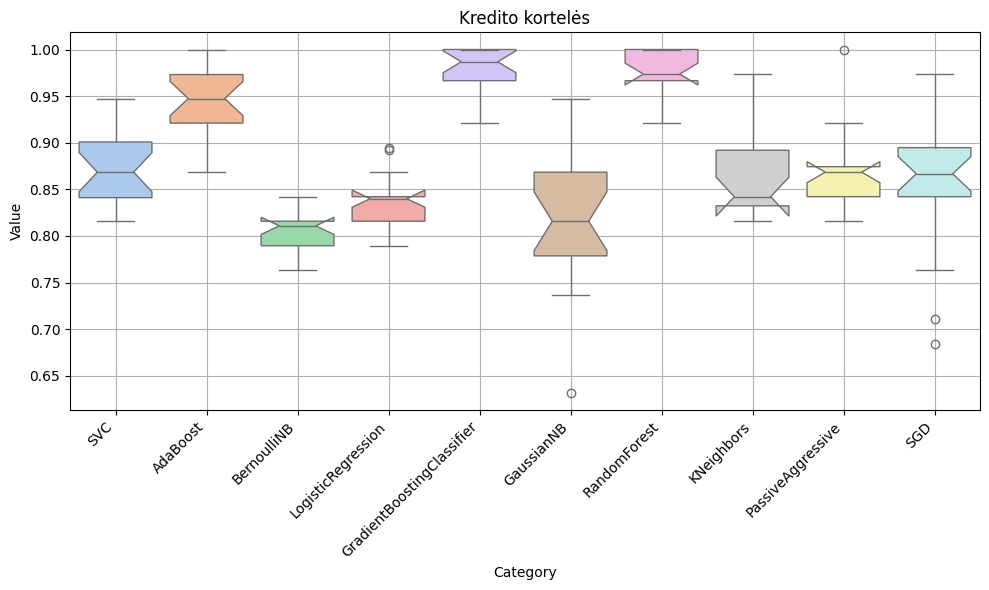

In [35]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20  + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20 + ['SGD']*20,
    'Value': np.concatenate([scores_svc_credit, scores_AdaBoost_credit, scores_BernoulliNB_credit, scores_lr_credit, scores_gb_credit, scores_gnb_credit, scores_rf_credit, scores_knn_credit, scores_pa_credit, scores_sgd_credit])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()